In [1]:
import pandas as pd

# 1. Load the traffic dataset (Replace with the exact filename you downloaded)
df = pd.read_csv("train_aWnotuB.csv")

df.shape
df.columns
df.head()
df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [2]:
import pandas as pd

# Load train dataset
train = pd.read_csv('train_aWnotuB.csv')

# Convert DateTime string to actual datetime objects
train['DateTime'] = pd.to_datetime(train['DateTime'])

# Extract useful time elements
train['Hour'] = train['DateTime'].dt.hour
train['DayOfWeek'] = train['DateTime'].dt.dayofweek # 0=Monday, 6=Sunday

# Let's find out which junction is the most crowded on average!
junction_traffic = train.groupby('Junction')['Vehicles'].mean().reset_index()
print("--- Average Number of Vehicles per Junction ---")
print(junction_traffic)

--- Average Number of Vehicles per Junction ---
   Junction   Vehicles
0         1  45.052906
1         2  14.253221
2         3  13.694010
3         4   7.251611


In [3]:
print(train.shape)

print(train.describe())

print(train['Junction'].value_counts())

(48120, 6)
                            DateTime      Junction      Vehicles  \
count                          48120  48120.000000  48120.000000   
mean   2016-09-19 06:03:56.109725696      2.180549     22.791334   
min              2015-11-01 00:00:00      1.000000      1.000000   
25%              2016-04-16 01:45:00      1.000000      9.000000   
50%              2016-09-30 03:30:00      2.000000     15.000000   
75%              2017-02-25 16:00:00      3.000000     29.000000   
max              2017-06-30 23:00:00      4.000000    180.000000   
std                              NaN      0.966955     20.750063   

                 ID          Hour     DayOfWeek  
count  4.812000e+04  48120.000000  48120.000000  
mean   2.016330e+10     11.500000      2.996010  
min    2.015110e+10      0.000000      0.000000  
25%    2.016042e+10      5.750000      1.000000  
50%    2.016093e+10     11.500000      3.000000  
75%    2.017023e+10     17.250000      5.000000  
max    2.017063e+10     23

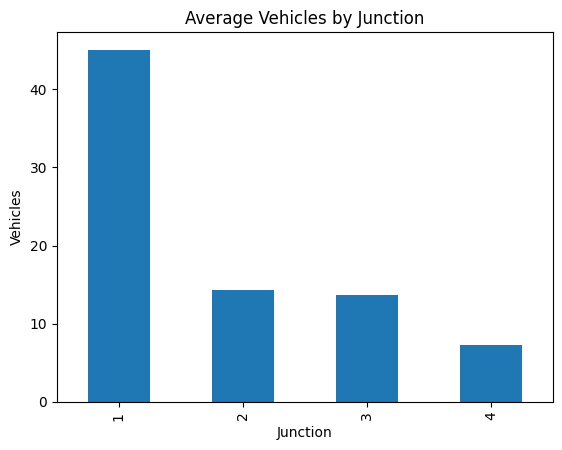

In [4]:
import matplotlib.pyplot as plt

junction_avg = train.groupby('Junction')['Vehicles'].mean()

junction_avg.plot(kind='bar')

plt.title("Average Vehicles by Junction")
plt.ylabel("Vehicles")

plt.show()

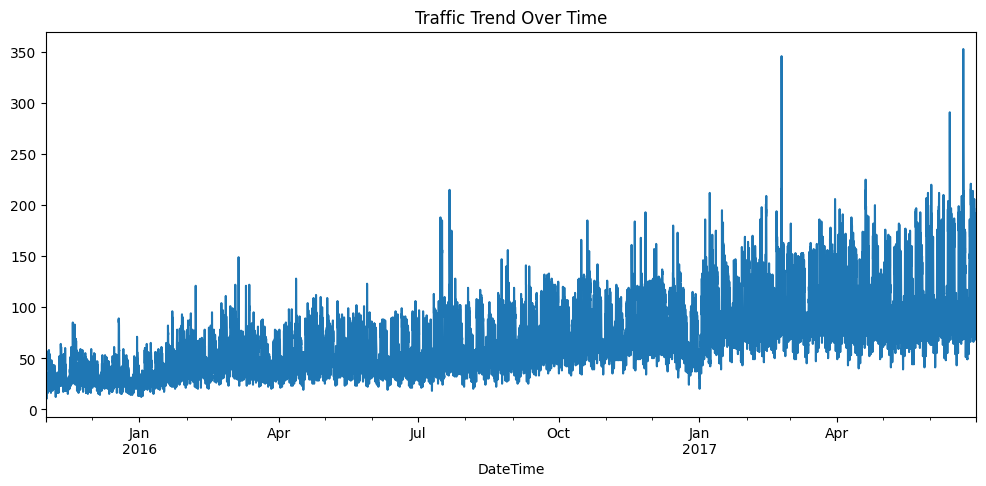

In [6]:
daily = train.groupby('DateTime')['Vehicles'].sum()

daily.plot(figsize=(12,5))

plt.title("Traffic Trend Over Time")

plt.show()

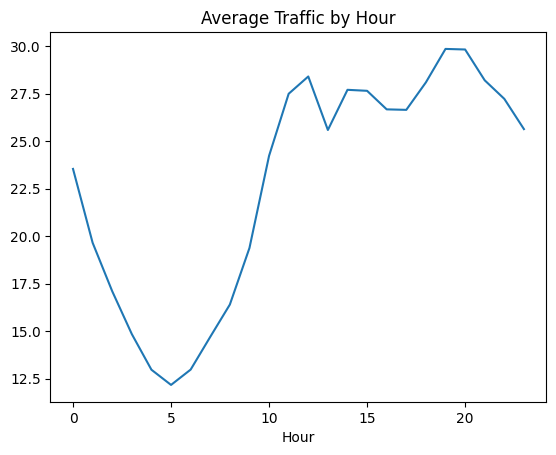

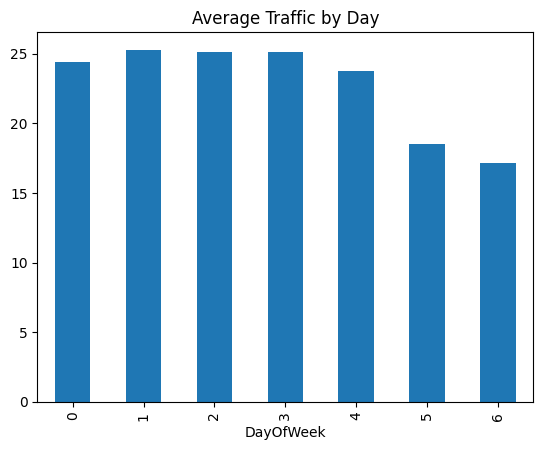

In [7]:
hourly = train.groupby('Hour')['Vehicles'].mean()

hourly.plot()

plt.title("Average Traffic by Hour")

plt.show()

day = train.groupby('DayOfWeek')['Vehicles'].mean()

day.plot(kind='bar')

plt.title("Average Traffic by Day")

plt.show()

In [12]:
train.describe()

,DateTime,Junction,Vehicles,ID,Hour,DayOfWeek
count,48120,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000
mean,2016-09-19 06:03:56.109725696,2.180549,22.791334,2.016330e+10,11.500000,2.996010
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10,0.000000,0.000000
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10,5.750000,1.000000
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10,11.500000,3.000000
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10,17.250000,5.000000
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10,23.000000,6.000000
std,NaN,0.966955,20.750063,5.944854e+06,6.922258,2.000017


In [13]:
train.groupby("Junction")["Vehicles"].max()

Junction
1    156
2     48
3    180
4     36
Name: Vehicles, dtype: int64

In [5]:
train['Month']=train['DateTime'].dt.month
train['Year']=train['DateTime'].dt.year
train['Is_Weekend']=train['DayOfWeek'].apply(lambda x: 1 if x>=5 else 6)
print(train[['DateTime', 'Month', 'Year', 'Is_Weekend']].head())

             DateTime  Month  Year  Is_Weekend
0 2015-11-01 00:00:00     11  2015           1
1 2015-11-01 01:00:00     11  2015           1
2 2015-11-01 02:00:00     11  2015           1
3 2015-11-01 03:00:00     11  2015           1
4 2015-11-01 04:00:00     11  2015           1


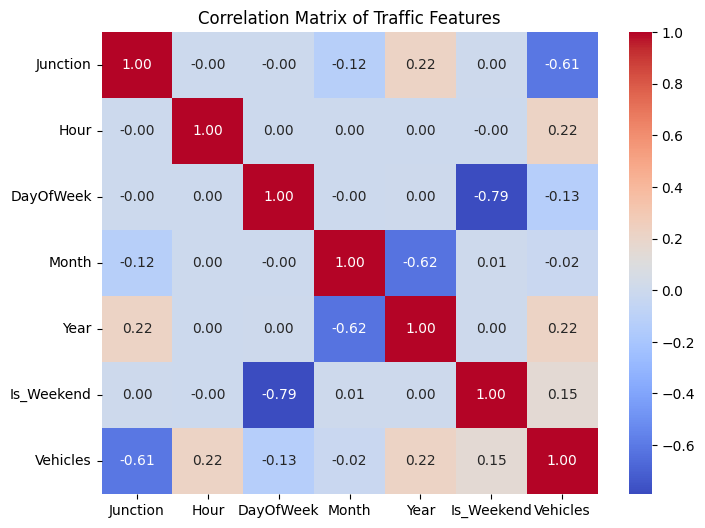

In [6]:
import seaborn as sns
features = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Vehicles']
plt.figure(figsize=(8, 6))
sns.heatmap(train[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Traffic Features")
plt.show()

In [7]:
feature_cols = ['Junction', 'Hour', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend']
target_col = 'Vehicles'
train = train.sort_values('DateTime').reset_index(drop=True)

X = train[feature_cols]
y = train[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48120, 6)
Target shape: (48120,)


Mean Vehicle Count: 22.79
Median Vehicle Count: 15.00
Standard Deviation: 20.75
Variance: 430.57
Skewness: 1.82 (Positive skew means occasional massive traffic spikes)
Kurtosis: 3.39


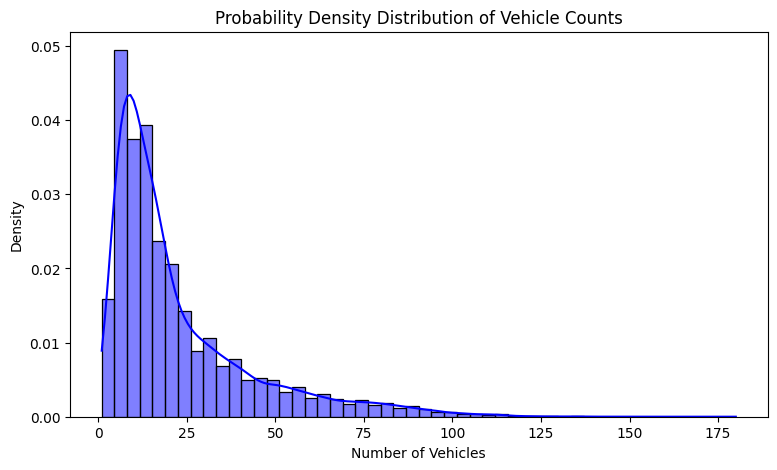

In [8]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data and extract time features just like Week 2
train = pd.read_csv('train_aWnotuB.csv')
train['DateTime'] = pd.to_datetime(train['DateTime'])
train['Hour'] = train['DateTime'].dt.hour

# 2. Calculate basic descriptive stats metrics manually to show the math
mean_v = train['Vehicles'].mean()
median_v = train['Vehicles'].median()
std_v = train['Vehicles'].std()
variance_v = train['Vehicles'].var()

print(f"Mean Vehicle Count: {mean_v:.2f}")
print(f"Median Vehicle Count: {median_v:.2f}")
print(f"Standard Deviation: {std_v:.2f}")
print(f"Variance: {variance_v:.2f}")

# 3. Calculate Skewness and Kurtosis to understand the probability distribution shape
# Positive skewness means a long tail of extreme traffic peak hours
skew_v = train['Vehicles'].skew()
kurt_v = train['Vehicles'].kurt()
print(f"Skewness: {skew_v:.2f} (Positive skew means occasional massive traffic spikes)")
print(f"Kurtosis: {kurt_v:.2f}")

# 4. Plot the Probability Density Function (PDF) vs Normal Distribution
plt.figure(figsize=(9, 5))
sns.histplot(train['Vehicles'], kde=True, stat="density", color="blue", bins=50)
plt.title("Probability Density Distribution of Vehicle Counts")
plt.xlabel("Number of Vehicles")
plt.ylabel("Density")
plt.show()

In [8]:
print(train['Vehicles'].describe())

count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64


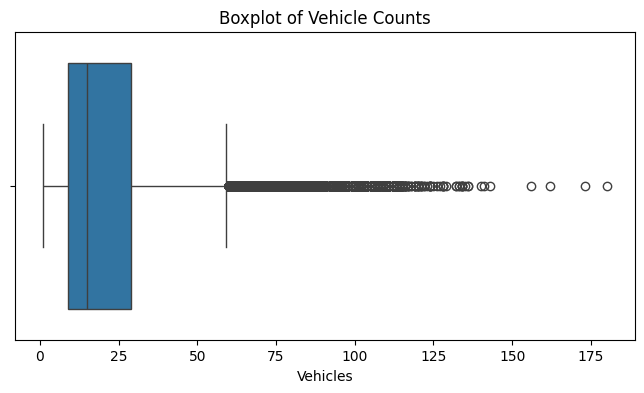

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=train["Vehicles"])
plt.title("Boxplot of Vehicle Counts")
plt.show()

In [9]:
split = int(len(train) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(38496, 6) (9624, 6)


In [10]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = lr_model.predict(X_test)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.6285513651877115
MAE: 11.492852393957909
RMSE: 16.592558544360454


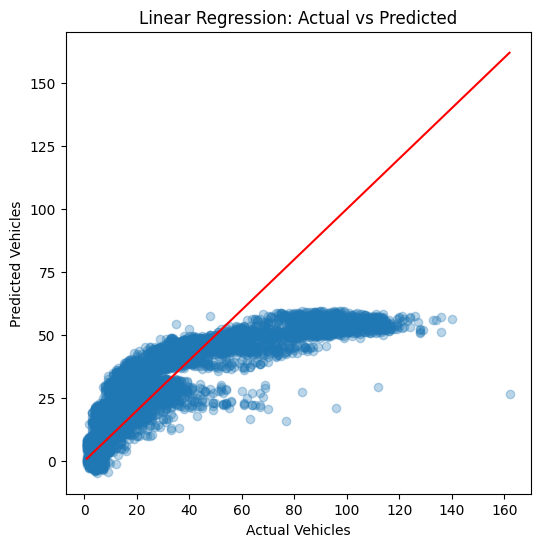

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [14]:
print("R² :", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

R² : 0.9160200238724633
MAE: 4.808486954130657
RMSE: 7.8895430235196145


In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R²": [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.628551,11.492852,16.592559
1,Random Forest,0.916020,4.808487,7.889543


      Feature  Importance
0    Junction    0.550781
1        Hour    0.149223
4        Year    0.135477
3       Month    0.088207
2   DayOfWeek    0.046546
5  Is_Weekend    0.029767


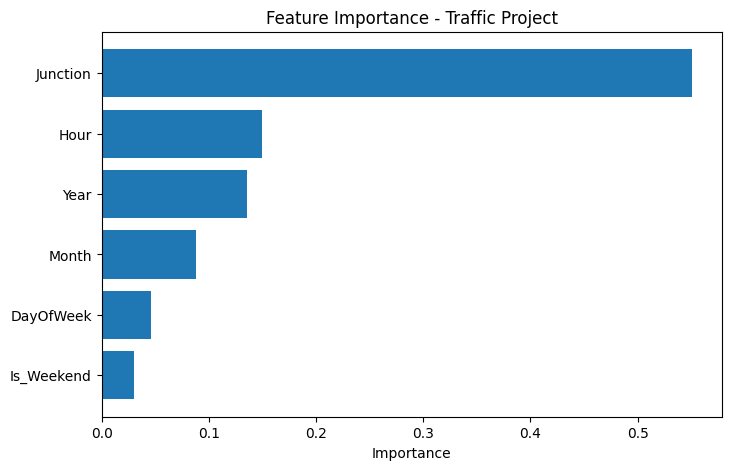

In [16]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Feature Importance - Traffic Project")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()